Test 1: 3000행
Test 2: 3000행
Test 3: 3000행
Test 4: 3000행
Test 5: 3000행
Test 6: 3000행

총 피처 수: 39개


C:\Users\이하연\AppData\Local\Temp\ipykernel_19968\202562348.py:68: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\이하연\AppData\Local\Temp\ipykernel_19968\202562348.py:68: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\이하연\AppData\Local\Temp\ipykernel_19968\202562348.py:68: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\이하연\AppData\Local\Temp\ipykernel_19968\202562348.py:68: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\이하연\AppData\Local\Temp\ipykernel_19968\202562348.py:68: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\이하연\AppData\Local\Temp\ipykernel_19968\202562348.py:68: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.

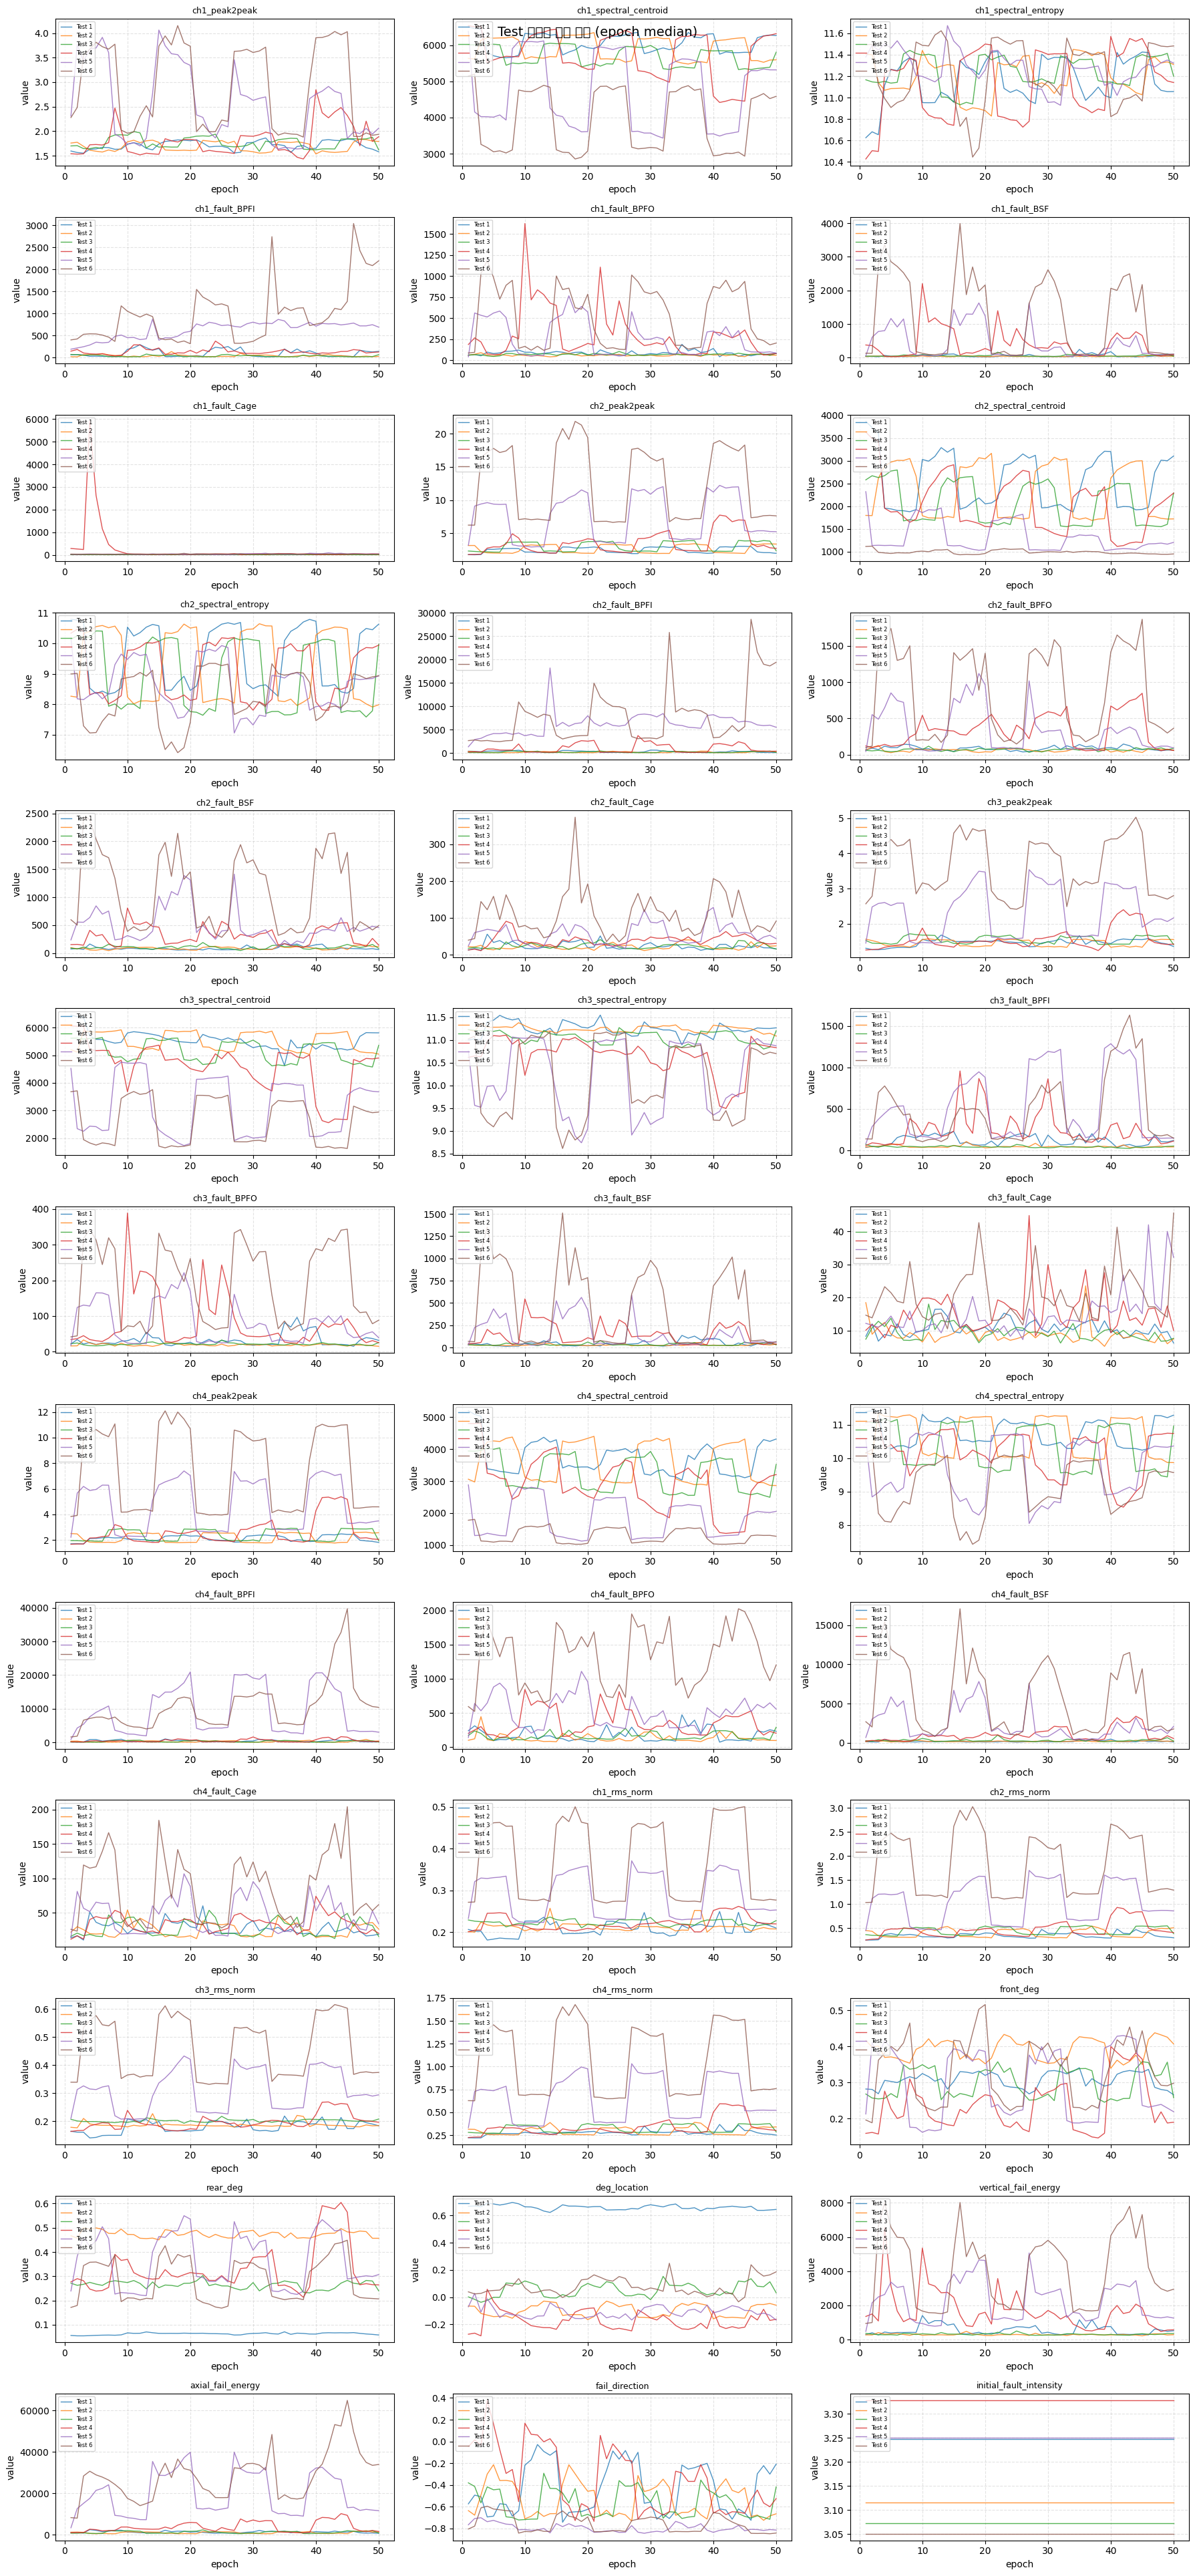

저장 완료 → ../output/test_feature_distribution.png


In [1]:
# ============================================================
# Test 데이터 분포 시각화
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import os, glob, re
import numpy as np

TEST_PATH = '../data/Test'

# Test 데이터 로드
test_dfs = {}
test_folders = glob.glob(os.path.join(TEST_PATH, 'Test*'))
test_nums    = sorted([
    int(re.search(r'Test(\d+)', os.path.basename(f)).group(1))
    for f in test_folders if os.path.isdir(f)
    and re.search(r'Test(\d+)', os.path.basename(f))
])

for t in test_nums:
    path = os.path.join(TEST_PATH,
                        f'Test{t}_Vibration_featured_summary.csv')
    if os.path.exists(path):
        test_dfs[t] = pd.read_csv(path)
        print(f'Test {t}: {len(test_dfs[t])}행')

# 피처 컬럼 추출
meta_cols = ['epoch', 'window', 't_abs', 'rpm_pred', 'test_id']
feat_cols = [c for c in test_dfs[test_nums[0]].columns
             if c not in meta_cols]
print(f'\n총 피처 수: {len(feat_cols)}개')

# ── epoch 단위 median 집계 ─────────────────────────────────
test_epoch_dfs = {}
for t, df in test_dfs.items():
    test_epoch_dfs[t] = df.groupby('epoch')[feat_cols].median().reset_index()

# ── 열별 Test1~6 분포 시각화 ──────────────────────────────
COLORS = ['tab:blue', 'tab:orange', 'tab:green',
          'tab:red',  'tab:purple', 'tab:brown']

n_cols = 3
n_rows = (len(feat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(18, n_rows * 3))
axes = axes.flatten()
fig.suptitle('Test 데이터 피처 분포 (epoch median)', fontsize=14)

for idx, feat in enumerate(feat_cols):
    ax = axes[idx]
    for i, (t, df) in enumerate(test_epoch_dfs.items()):
        if feat not in df.columns:
            continue
        ax.plot(df['epoch'], df[feat],
                color=COLORS[i], linewidth=1.0,
                alpha=0.8, label=f'Test {t}')
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('epoch')
    ax.set_ylabel('value')
    ax.legend(fontsize=6, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.35)

# 빈 subplot 숨기기
for idx in range(len(feat_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
os.makedirs('../output', exist_ok=True)
plt.savefig('../output/test_feature_distribution.png',
            bbox_inches='tight', dpi=100)
plt.show()
print('저장 완료 → ../output/test_feature_distribution.png')

In [2]:
# Test1 vs 다른 Test 비교
import pandas as pd
import numpy as np
import os

TEST_PATH = '../data/Test'

# 주요 피처만 비교
key_feats = [
    'ch1_fault_BPFI', 'ch1_fault_BPFO', 'ch1_fault_BSF',
    'ch4_fault_BPFI', 'ch4_fault_BPFO', 'ch4_fault_BSF',
    'ch1_rms_norm', 'ch4_rms_norm',
    'front_deg', 'rear_deg',
    'initial_fault_intensity', 't_abs'
]

print('=== Test별 마지막 epoch 피처값 비교 ===')
rows = []
for t in test_nums:
    path = os.path.join(TEST_PATH,
                        f'Test{t}_Vibration_featured_summary.csv')
    df   = pd.read_csv(path)
    last = df.loc[df['t_abs'].idxmax()]
    row  = {'Test': f'Test{t}'}
    for f in key_feats:
        if f in last.index:
            row[f] = round(float(last[f]), 2)
    rows.append(row)

df_cmp = pd.DataFrame(rows).set_index('Test')
print(df_cmp.to_string())

=== Test별 마지막 epoch 피처값 비교 ===
       ch1_fault_BPFI  ch1_fault_BPFO  ch1_fault_BSF  ch4_fault_BPFI  ch4_fault_BPFO  ch4_fault_BSF  ch1_rms_norm  ch4_rms_norm  front_deg  rear_deg  initial_fault_intensity    t_abs
Test                                                                                                                                                                                  
Test1          185.25           76.29          14.31          174.68          243.77         128.13          0.21          0.25       0.27      0.06                     3.25  29459.5
Test2          105.89           81.21          37.80          396.01           89.57          75.34          0.26          0.43       0.43      0.46                     3.12  29459.5
Test3          146.92           86.61          33.74          211.82          409.90          63.24          0.23          0.29       0.27      0.26                     3.07  29459.5
Test4          155.25          125.86          98.44  